In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

### Data Loading

In [46]:

car_dataset = pd.read_csv('car.csv')

In [47]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [48]:
car_dataset.shape

(301, 9)

In [49]:
car_dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [50]:
car_dataset.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [51]:
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Year.value_counts())
print(car_dataset.Selling_Price.value_counts())
print(car_dataset.Owner.value_counts())
print(car_dataset.Kms_Driven.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Year
2015    61
2016    50
2014    38
2017    35
2013    33
2012    23
2011    19
2010    15
2008     7
2009     6
2005     4
2006     4
2007     2
2003     2
2018     1
2004     1
Name: count, dtype: int64
Selling_Price
0.45     8
0.60     8
4.50     7
5.25     7
4.75     6
        ..
10.11    1
6.40     1
8.55     1
9.50     1
11.50    1
Name: count, Length: 156, dtype: int64
Owner
0    290
1     10
3      1
Name: count, dtype: int64
Kms_Driven
15000    9
45000    9
40000    5
25000    5
50000    5
        ..
60076    1
33988    1
87934    1
9000     1
5464     1
Name: count, Length: 206, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [52]:

current_year = datetime.datetime.now().year
car_dataset['Years_old'] = current_year - car_dataset['Year']
car_dataset.drop('Year', axis=1, inplace=True)

In [53]:
# Drop the 'Car_Name' column which is causing the error
car_dataset.drop('Car_Name', axis=1, inplace=True)

In [54]:
# One-hot encode categorical features
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
car_dataset_encoded = pd.get_dummies(car_dataset, columns=categorical_cols, drop_first=True)

In [55]:
print(car_dataset_encoded.head())

   Selling_Price  Present_Price  Kms_Driven  Years_old  Fuel_Type_Diesel  \
0           3.35           5.59       27000         11             False   
1           4.75           9.54       43000         12              True   
2           7.25           9.85        6900          8             False   
3           2.85           4.15        5200         14             False   
4           4.60           6.87       42450         11              True   

   Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual  Owner_1  \
0              True                   False                 True    False   
1             False                   False                 True    False   
2              True                   False                 True    False   
3              True                   False                 True    False   
4             False                   False                 True    False   

   Owner_3  
0    False  
1    False  
2    False  
3    False  
4    False  


### Splitting the Data into Training and Testing Sets

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X = car_dataset_encoded.drop('Selling_Price',axis=1)
y = car_dataset_encoded['Selling_Price']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
X_train

,Present_Price,Kms_Driven,Years_old,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Owner_1,Owner_3
184,0.750,26000,17,False,True,True,True,True,False
132,0.950,3500,8,False,True,True,True,False,False
194,0.787,50000,17,False,True,True,True,False,False
75,6.800,36000,10,False,True,False,True,False,False
111,1.500,8700,9,False,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...
188,0.570,18000,12,False,True,True,True,False,False
71,12.480,45000,14,True,False,False,True,False,False
106,3.450,16500,11,False,True,True,True,True,False
270,10.000,69341,14,False,True,False,True,False,False


In [60]:
X_test

,Present_Price,Kms_Driven,Years_old,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Owner_1,Owner_3
177,0.57,24000,9,False,True,True,False,False,False
289,13.60,10980,9,False,True,False,True,False,False
228,9.40,60000,13,True,False,False,True,False,False
198,0.57,35000,14,False,True,True,True,True,False
60,18.61,40001,12,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
234,5.70,4492,10,False,True,False,True,False,False
296,11.60,33988,9,True,False,False,True,False,False
281,7.60,50456,19,False,True,False,True,False,False
285,8.50,15059,9,False,True,False,False,False,False


In [61]:
y_train

184    0.25
132    0.75
194    0.20
75     3.95
111    1.15
       ... 
188    0.25
71     4.50
106    1.35
270    4.10
102    1.65
Name: Selling_Price, Length: 240, dtype: float64

In [62]:
y_test

177     0.35
289    10.11
228     4.95
198     0.15
60      6.95
       ...  
234     5.50
296     9.50
281     2.10
285     7.40
182     0.30
Name: Selling_Price, Length: 61, dtype: float64

### Training the Linear Regression Model

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [64]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)

In [66]:
X_train[ :7]

,Present_Price,Kms_Driven,Years_old,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Owner_1,Owner_3
184,0.750,26000,17,False,True,True,True,True,False
132,0.950,3500,8,False,True,True,True,False,False
194,0.787,50000,17,False,True,True,True,False,False
75,6.800,36000,10,False,True,False,True,False,False
111,1.500,8700,9,False,True,True,True,False,False
59,35.960,41000,11,True,False,False,False,False,False
93,30.610,40000,10,True,False,False,False,False,False


In [67]:
y_train[ :7]

184     0.25
132     0.75
194     0.20
75      3.95
111     1.15
59     19.99
93     23.00
Name: Selling_Price, dtype: float64

In [68]:
y_train_pred[ :7]

array([-1.21957875,  1.89880072, -1.62756073,  4.70530928,  1.75400759,
       20.47886084, 18.5133529 ])

In [69]:
X_test[ :7]

,Present_Price,Kms_Driven,Years_old,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Owner_1,Owner_3
177,0.57,24000,9,False,True,True,False,False,False
289,13.60,10980,9,False,True,False,True,False,False
228,9.40,60000,13,True,False,False,True,False,False
198,0.57,35000,14,False,True,True,True,True,False
60,18.61,40001,12,False,True,False,True,False,False
9,8.92,42367,10,True,False,False,True,False,False
118,1.47,26000,10,False,True,True,True,False,False


In [70]:
y_test[ :7]

177     0.35
289    10.11
228     4.95
198     0.15
60      6.95
9       7.45
118     1.10
Name: Selling_Price, dtype: float64

In [71]:
y_test_pred[ :7]

array([ 3.02322333,  8.15073777,  6.35635055, -0.27278447,  9.10896196,
        7.31033492,  1.29427179])

In [72]:
plot_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})

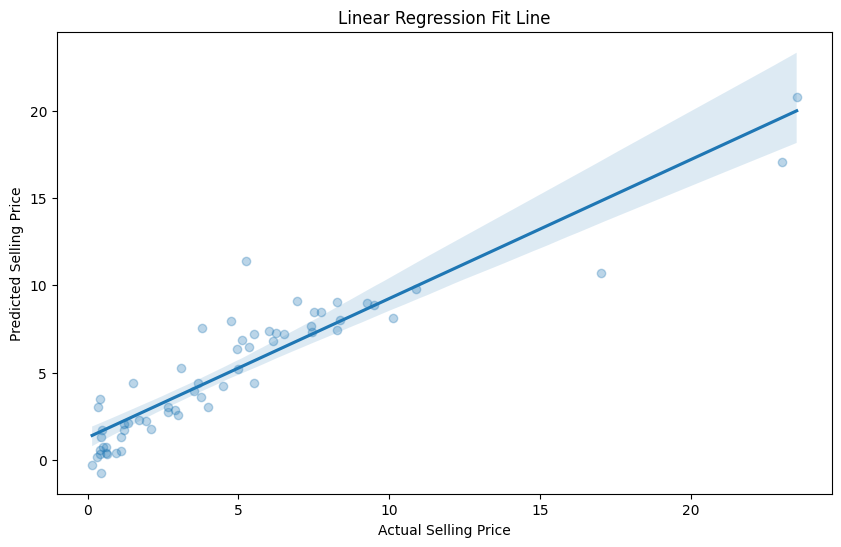

In [73]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_test_pred, scatter_kws={'alpha':0.3})
plt.title('Linear Regression Fit Line')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.show()

### Training Model(Random Forest)

In [74]:
from sklearn.ensemble import RandomForestRegressor

In [75]:
random_model = RandomForestRegressor()
random_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
y_train_pred_random=random_model.predict(X_train)
y_test_pred_random=random_model.predict(X_test)

In [77]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

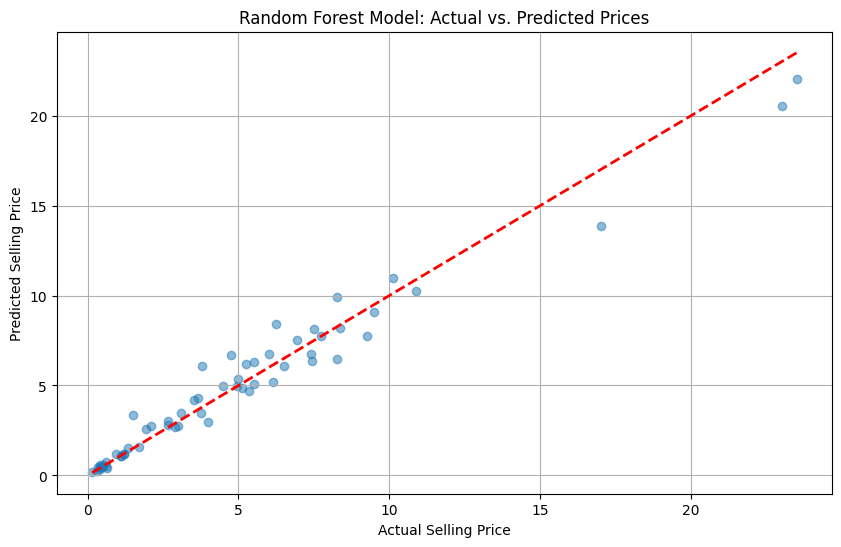

In [78]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_random, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest Model: Actual vs. Predicted Prices')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.grid(True)
plt.show()